### Import Dependencies

In [26]:
import openai
import pandas as pd
from qdrant_client import QdrantClient, models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier,PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Literal, Annotated, List, Any
from operator import add
import random
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
import instructor
from langsmith import traceable, get_current_run_tree
from openai import OpenAI
import os
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages

In [43]:
from langchain_openai import ChatOpenAI

Define Retrievel Tool

State and Pydantic Models for Structured Outputs

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from qdrant_client import QdrantClient
from qdrant_client.models import Distance,VectorParams,PointStruct
load_dotenv()
client=OpenAI()





# Qdrant host: "http://qdrant:6333" inside docker-compose, "http://localhost:6333" locally.
QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")
qdrant_client=QdrantClient(url="http://localhost:6333/")

def get_embedding(text,model="text-embedding-3-small"):
    response=client.embeddings.create(
        model=model,
        input=text
    )
    
    return response.data[0].embedding

def reteriver_data(query, qdrant_client=qdrant_client, k=5):
    query_embedding = get_embedding(query)

    result = qdrant_client.query_points(
        collection_name="Amazon_items_collection-00",
        query=query_embedding,
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_rating = []
    retrieved_image_urls = []
    retrieved_prices = []

    for point in result.points:
        payload = point.payload or {}
        retrieved_context_ids.append(payload.get("parent_asin"))
        retrieved_context.append(payload.get("description", ""))
        retrieved_context_rating.append(payload.get("average_rating"))
        similarity_scores.append(point.score)
        retrieved_image_urls.append(payload.get("image_url", ""))
        retrieved_prices.append(payload.get("price"))

    return (
        retrieved_context,
        retrieved_context_ids,
        retrieved_context_rating,
        similarity_scores,
        retrieved_image_urls,
        retrieved_prices
    )


def process_context(context, ids, ratings, scores):
    formatted_context = ""

    for id, chunk, rating, score in zip(ids, context, ratings, scores):
        formatted_context += (
            f"- ID: {id}\n"
            f"  Description: {chunk}\n"
            f"  Rating: {rating}\n"
            f"  Similarity Score: {score:.4f}\n\n"
        )

    return formatted_context

def build_prompt(processed_context, question):
    prompt = f"""
You are a helpful AI shopping assistant.

Use ONLY the information provided in the retrieved product context below to answer the user's question.

Rules:
- Do not make up information.
- If the answer is not present in the context, reply:
  "I couldn't find that information in the retrieved products."
- Keep your answer concise and helpful.
- Mention product IDs when relevant.

======================
Retrieved Context:
{processed_context}
======================

User Question:
{question}

Answer:
"""

    return prompt

def generate_chat(prompt):
    response = client.chat.completions.create(
        model="gpt-4.1-nano",
        messages=[
            {
                "role": "system",
                "content": prompt
            },
            
        ],
        temperature=0.2,
        max_tokens=300
    )

    return response.choices[0].message.content


def rag_pipeline(question, top_k=5):
    qdrant_client = QdrantClient(QDRANT_URL)

    retrieved_context = reteriver_data(
        question,
        qdrant_client,
        top_k
    )
   
    processed_context = process_context(
        retrieved_context[0],
        retrieved_context[1],
        retrieved_context[2],
        retrieved_context[3]
    )

    prompt = build_prompt(
        processed_context,
        question
    )
    
    answer = generate_chat(prompt)
    final_result={
        "answer":answer,
        "Question":question,
        "reterived_context_ids":retrieved_context[1],
        "reterived_context":retrieved_context[0],
        "similaritry_ecore":retrieved_context[3]
    }
    return final_result


def get_formatted_context(query: str, top_k: int = 5) -> str:
    """ Get the top k context each representing an inventory 
      item for a given query

    Args:
       query: The Query to get The top k context for
       top_k: The number of context chunks to retrieve, works best with 5 or more

    Returns:
       A string of the top k context chunks with IDs and the average ratings prepending 
       each chunk, each representing an inventory item
    """
    q_client = QdrantClient(url="http://localhost:6333/")
    context = reteriver_data(query=query, qdrant_client=q_client, k=top_k)
    formatted_context = process_context(
        context=context[0],
        ids=context[1],
        ratings=context[2],
        scores=context[3]
    )
    return formatted_context


    




c:\Users\jaysi\Desktop\Desktop\Ai-engineering\.venv\Lib\site-packages\qdrant_client\qdrant_remote.py:290: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


In [10]:
class RAGUsedContext(BaseModel):
    id:str=Field(description="The ID Of the item used answer the questions")
    description:str=Field(description="Short description of the item used to answer the Question")


class Toolcall(BaseModel):
    name:str
    arguments:dict

class FinalResponse(BaseModel):
    answer: str = Field(description="The answer to the user's question")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages:Annotated[List[Any],add]=[]
    question_relevant:bool=False 
    iteration:int=0
    answer:str=""
    available_tools:List[dict[str,Any]]=[]
    tool_calls:List[Toolcall]=[]
    final_answer:bool=False
    refernce:Annotated[List[RAGUsedContext],add]=[]

In [47]:
@traceable(
    name= "agent_node",
    run_type= "llm",
    metadata= {
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    prompt_template = f"""
    You are a shopping assistant that answers questions about products in stock.

    ## Instructions
    - Use the available tools to answer the user's question. Do not fabricate product details
    - When a questions involves multiple products or sub-questions, issue all the tools calls at once. Never repeat a tool call you have already made.
    - When describing the product, include the details using bullet points
    - If tools return no relevant resulkts, tell the customer and ask them to refine their query
    - Only answer questions about products in stock. If a question is unrelated, ask the customer to refine their query and include what products they are looking for
    - In references, include every chunk that contributed to the answer, with the chunk ID and product name
    - Refer to retrieved data as "available products", never as "context"
    - Try answering queries that are not precise, if speficic names or brands are missing apply broad searches
    """

    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort = "none",
        use_responses_api=True,
    )

    llm_with_tools = llm.bind_tools(
        [get_formatted_context, FinalResponse],
        tool_choice="any"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages #this lets the model reference the previous messages (the history)
        ]
    )

    final_answer = False
    answer = ""
    references = []

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get('name') == "FinalResponse":
                final_answer = True
                answer = tool_call.get('args').get('answer')
                references.extend(tool_call.get('args').get('references'))
                

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer,
        "references": references
    }

Tool Router Node

In [60]:
def tool_router(state: State) -> str:
    """Decide Whether to Continue or end"""
    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    else:
        last_message = state.messages[-1]
        # Check if the last AI message has pending tool calls
        tool_calls = getattr(last_message, 'tool_calls', [])
        non_final = [tc for tc in tool_calls if tc.get('name') != 'FinalResponse']
        if non_final:
            return "tools"
        return "end"


In [61]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if it's not relevant, saying that the question is not relevant to the products in stock")

In [62]:
def intent_router_node(state:State):
    prompt_template=""" You are part of a shopping assistant that can answer questions about product in stock

    Instruction:
    -You are given a question and you need to classify it into relevant or not relavant.
    -If the question is not relevant ,return False in Field ""question_relavant" and set "answer" to explanation why it is not relevant.
    -If the question is relevant , return True in field "question_relavant" and set "answer" to .
    - You should only answer question the products in stock. If the question is not about the products in stock ,you should ask for clarification
    <Question>
    {{query}}
    </Question>
    -
    """
    template = Template(prompt_template)
    prompt = template.render()

    messages = state.messages
    conversation = []
    
    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response,raw_response=client.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[
            {
                "role":"system",

                 "content":prompt,
            },
            *conversation
        ],
        temperature=0.5,
    )

    return {
        "question_relevant":response.question_relevant,
        "answer":response.answer
    }


In [38]:
def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

In [73]:
workflow = StateGraph(State)

tools = [get_formatted_context]

tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END 
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END 
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()


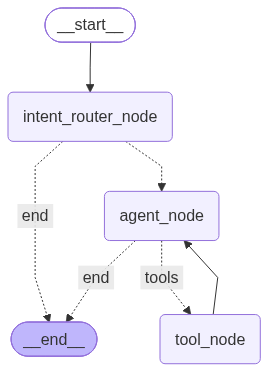

In [65]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [79]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for me, a watch for my wife and a laptop for my daughter?")]
}

In [80]:
result = graph.invoke(initial_state)

In [81]:
result

{'messages': [HumanMessage(content='Can I get a tablet for me, a watch for my wife and a laptop for my daughter?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"tablet available products in stock","top_k":5}', 'call_id': 'call_4S0gL4SEmEN7bMR367M68vpn', 'name': 'get_formatted_context', 'type': 'function_call', 'id': 'fc_0add9d1f49c9a799006a83ffb23da087d09a696f686c803452', 'status': 'completed'}, {'arguments': '{"query":"watch available products in stock","top_k":5}', 'call_id': 'call_YnIXO8ye5HWScVb9tR5CxGTy', 'name': 'get_formatted_context', 'type': 'function_call', 'id': 'fc_0add9d1f49c9a799006a83ffb23db487d0a11125141ccfd61b', 'status': 'completed'}, {'arguments': '{"query":"laptop available products in stock","top_k":5}', 'call_id': 'call_Ejxd378bDZhh6zO62uYyEZi8', 'name': 'get_formatted_context', 'type': 'function_call', 'id': 'fc_0add9d1f49c9a799006a83ffb23dbc87d09b8a355bd3cef376', 'status': 'completed'}], additional_kwargs={}, response

In [82]:
print(result['answer'])

Yes — I found available products for all three items:

- Tablet for you:
  - Paxodo Kids Tablet, 10 inch, Android 10, 32GB ROM, 6000mAh, WiFi, parental control, kid-proof case
  - COOPERS 7 inch Kids Tablet, Android 11, 32GB ROM, WiFi, parental control
  - Note: these are kids tablets, so if you want a more general-use tablet, please refine your query.

- Watch for your wife:
  - HYSTORM Health Smart Watch, 1.43" AMOLED, Bluetooth calling, health tracking, Android/iOS compatible
  - Smart Watch, 1.69" full touch screen, Bluetooth calling, IP68 waterproof, Android/iOS compatible

- Laptop for your daughter:
  - Acer Aspire 5 A515-56-347N Slim Laptop, 15.6" FHD, Intel i3, 8GB RAM, 128GB SSD, Windows 11 Home S Mode

If you want, I can help narrow these down by age, budget, or preferred size/features.
